Dataset: Fraud in electricity and gas consumption


Dataset Information:
This dataset contains the client information for over 21000 people, each of them can have 3-50 invoices (see “invoice.csv”). The common column between the two csv files is “id”. Your job is to analyze the pattern of their consumption and find out which clients are fraud. Remember that you need to classify the client and not the transaction (a client performing 3-50 transactions). You are expected to apply various innovative techniques in – (1) handling the data imbalance issue and (2) summarizing the variable number of transaction info for each client.

data:
  - client: (21,652)
    - region --> int
    - date (date client joined) --> (1978 ~ 2019) datetime
    - dis --> {60, 62, 63, 69} int
    - catg --> {11, 12, 51} int
    - id --> str
    - target --> int / bool (0/1)
  - invoice: (500,651)
    - id --> str
    - date (date of invoice) --> datetime
    - tarif --> {9,10,11,12,13,14,15,21,29,30,40,45} int
    - counter_number --> int
    - counter_statue --> [0:5] int
    - counter_code --> int
    - reading remarque --> {6,7,8,9} int
    - consommation level (1,2,3,4) --> int
    - index (old, new) --> int
    - months_number --> int
    - counter_type --> (ELEC or GAZ) str
    - counter_coefficient --> {1,2,3,20} int
    



## K nearest neighbours (KNN)


### Prerequisites

In [6]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score #check if needed
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
pd.set_option('display.max_columns', 500)

### Preprocessing

#### Merging the CSVs

In [7]:
# merge 'client.csv' and 'invoice.csv' by client id

with open('../Dataset/client.csv') as f:
        reader = csv.reader(f, delimiter=",")
        client_lst = list(reader)
        client_lst = client_lst[1:]
with open('../Dataset/invoice.csv') as f:
        reader = csv.reader(f, delimiter=",")
        invoice_lst = list(reader)
        invoice_lst = invoice_lst[1:]


In [ ]:

client_variables = ['region', 'date', 'dis', 'id', 'catg', 'target']
invoice_variables = ['id', 'date', 'tarif_type', 'counter_number', 'counter_statue', 'counter_code', 'reading_remarque', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_type', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3']
combined_variables = ['id', 'invoice_date', 'tarif_type', 'counter_number', 'counter_statue', 'counter_code', 'reading_remarque', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_type', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'region', 'joined_date', 'dis', 'catg', 'target']
clients = {}
for i in client_lst:
  clients[i[3]] = i[:3] + i [4:]

merged_lst = invoice_lst.copy()
for i in merged_lst:
  for j in clients[i[0]]:
    i.append(j)

merged_df = pd.DataFrame(merged_lst, columns = combined_variables)


#### Change Variable Types

In [ ]:
format = '%d/%m/%Y'
int_cols = [
    "tarif_type", "counter_statue", "counter_code", "reading_remarque","consommation_level_1", "consommation_level_2", "consommation_level_3",
    "consommation_level_4", "old_index", "new_index", "months_number", "counter_coefficient", "region", "dis", "catg", "target"
]

merged_df['invoice_date'] = pd.to_datetime(merged_df['invoice_date'], format = format)
merged_df['joined_date'] = pd.to_datetime(merged_df['joined_date'], format = format)
merged_df['counter_number'] = merged_df['counter_number'].astype(float)
for col in int_cols:
    merged_df[col] = merged_df[col].astype(int)

#### Encoding Categorical Variable
We can convert the `counter_type` column to `is_elec` since this column only has 2 possible values.

In [ ]:
merged_df['is_elec'] = merged_df['counter_type'].apply(lambda x: 1 if x == 'ELEC' else 0)
merged_df = merged_df.drop('counter_type', axis=1)

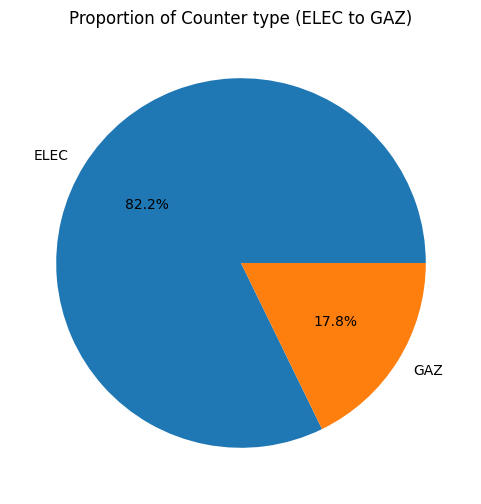

In [ ]:
C=merged_df['is_elec'].tolist()
elec=C.count(1)*100/len(C)
gaz=C.count(0)*100/len(C)
plt.figure(figsize=(6,6))
plt.pie([elec,gaz], labels = ['ELEC','GAZ'],autopct='%1.1f%%')
plt.title("Proportion of Counter type (ELEC to GAZ)")
plt.show()

#### Removing ID Columns

In [ ]:
merged_df = merged_df.drop(['id', 'old_index', 'new_index',], axis=1)

#### Separate Date Components to Each Own Column

In [ ]:
date_cols = ["invoice_date", "joined_date"]

for col in date_cols:
  merged_df[col + "_year"] = merged_df[col].dt.year
  merged_df[col + "_month"] = merged_df[col].dt.month
  merged_df[col + "_day"] = merged_df[col].dt.day

merged_df = merged_df.drop(date_cols, axis=1)

#### Resulting Merged DataFrame

In [ ]:
merged_df.head()

,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,consommation_level_4,months_number,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,region,dis,catg,target,is_elec,invoice_date_year,invoice_date_month,invoice_date_day,joined_date_year,joined_date_month,joined_date_day
0,11,1335667.0,0,203,8,0,4,1,82,0,0,101,60,11,0,1,2014,3,24,1994,12,31
1,11,1335667.0,0,203,6,0,4,1,1200,184,0,101,60,11,0,1,2013,3,29,1994,12,31
2,11,1335667.0,0,203,8,0,4,1,123,0,0,101,60,11,0,1,2015,3,23,1994,12,31
3,11,1335667.0,0,207,8,0,4,1,102,0,0,101,60,11,0,1,2015,7,13,1994,12,31
4,11,1335667.0,0,207,9,0,12,1,572,0,0,101,60,11,0,1,2016,11,17,1994,12,31


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500651 entries, 0 to 500650
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   tarif_type            500651 non-null  int64  
 1   counter_number        500651 non-null  float64
 2   counter_statue        500651 non-null  int64  
 3   counter_code          500651 non-null  int64  
 4   reading_remarque      500651 non-null  int64  
 5   consommation_level_4  500651 non-null  int64  
 6   months_number         500651 non-null  int64  
 7   counter_coefficient   500651 non-null  int64  
 8   consommation_level_1  500651 non-null  int64  
 9   consommation_level_2  500651 non-null  int64  
 10  consommation_level_3  500651 non-null  int64  
 11  region                500651 non-null  int64  
 12  dis                   500651 non-null  int64  
 13  catg                  500651 non-null  int64  
 14  target                500651 non-null  int64  
 15  

### Feature Engineering

#### Feature Selection

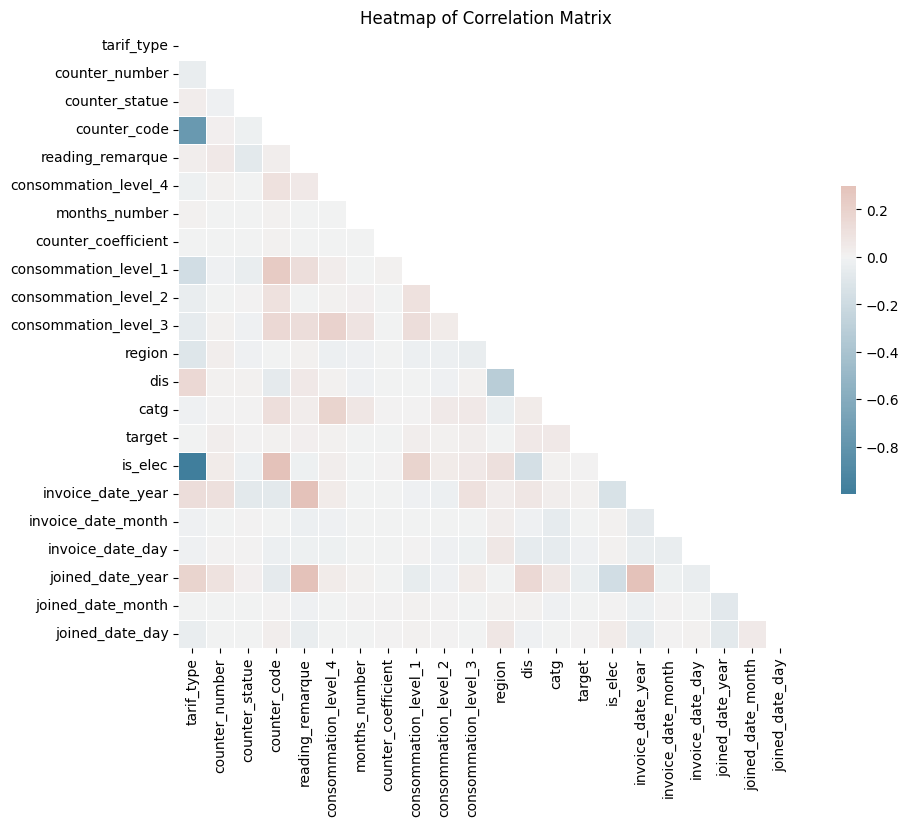

In [ ]:
# pairwise correlation of columns
# 22 x 22 matrix showing the correlation (value ranging between -1 and 1) between the row attribute and the column attribute for each entry
corr = merged_df.corr()

plt.figure(figsize=(12, 8))

# upper triangle
# parameter of heatmap, upper right section of heatmap uncoloured since it is symmetric with the lower right
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Heatmap of Correlation Matrix')
plt.show()

In [ ]:

corr_abs = corr.abs()
high_corr_columns = corr_abs['target'][corr_abs['target'] > 0.1].index.tolist()
high_corr_columns.remove('target')
print(high_corr_columns)

[]


Uh oh! There are no columns that are highly correlated to the `target` column. Because of this, we will use all of features

#### Handling Missing Values

In [ ]:
merged_df.isna().sum()

tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
consommation_level_4    0
months_number           0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
region                  0
dis                     0
catg                    0
target                  0
is_elec                 0
invoice_date_year       0
invoice_date_month      0
invoice_date_day        0
joined_date_year        0
joined_date_month       0
joined_date_day         0
dtype: int64

No need to handle! There are no missing values.

#### Handle Duplicated Values

In [ ]:
merged_df.duplicated().sum()

105

In [ ]:
merged_df = merged_df.drop_duplicates()

In [ ]:
merged_df.duplicated().sum()

0

### Modelling

#### Splitting the Dataset

In [ ]:
X = merged_df.drop(['target'], axis=1)
y = merged_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Standarization

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Handling Imbalanced Classes Using SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

#### Training

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_res, y_res)
y_pred = knn.predict(X_test_scaled)

In [ ]:
y_pred

array([0, 1, 1, ..., 0, 0, 1])

In [ ]:
knn2 = KNeighborsClassifier(n_neighbors=5)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Perform cross-validation and compute scores
scores = cross_validate(knn2, X_res, y_res, cv=3, scoring=scoring)

# For ROC-AUC
y_pred_prob = cross_val_predict(knn2, X_res, y_res, cv=3, method='predict_proba')
y_prob_pos = y_pred_prob[:, 1]
roc_auc_scores = roc_auc_score(y_res, y_prob_pos)

# Print the scores
print("Cross-validated accuracy scores:", scores['test_accuracy'])
print("Average accuracy score:", scores['test_accuracy'].mean())

print("Cross-validated precision scores:", scores['test_precision'])
print("Average precision score:", scores['test_precision'].mean())

print("Cross-validated recall scores:", scores['test_recall'])
print("Average recall score:", scores['test_recall'].mean())

print("Cross-validated F1 scores:", scores['test_f1_score'])
print("Average F1 score:", scores['test_f1_score'].mean())

print("ROC AUC scores:", roc_auc_scores)
print("Average ROC AUC score:", roc_auc_scores.mean())

Cross-validated accuracy scores: [0.89703514 0.89645168 0.89614754]
Average accuracy score: 0.896544787479761
Cross-validated precision scores: [0.83047927 0.82956063 0.82892239]
Average precision score: 0.8296540982731657
Cross-validated recall scores: [0.99773009 0.99793791 0.99833753]
Average recall score: 0.9980018438025987
Cross-validated F1 scores: [0.90645434 0.90599252 0.90577627]
Average F1 score: 0.9060743756332995
ROC AUC scores: 0.9688031567188818
Average ROC AUC score: 0.9688031567188818


#### Visualisation

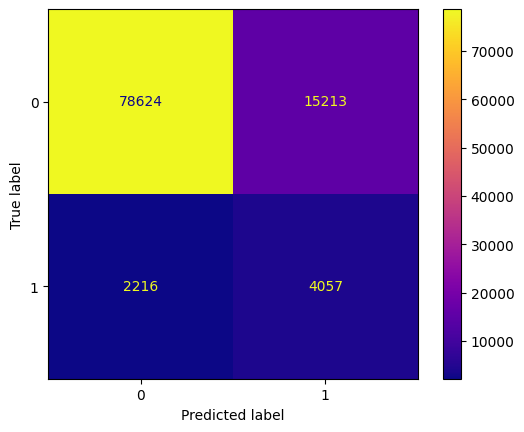

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

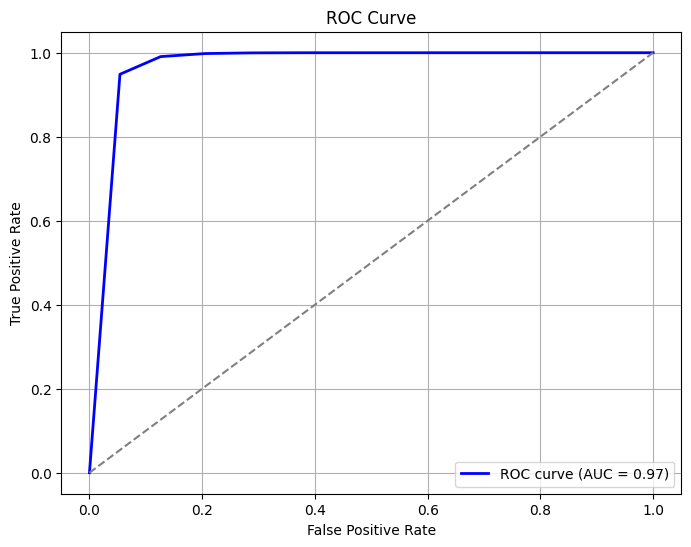

In [ ]:
#Generate ROC AUC Curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_res, y_prob_pos)
roc_auc = roc_auc_score(y_res, y_prob_pos)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Finding best number of neighbors

In [ ]:
from sklearn.model_selection import GridSearchCV

k_range = list(range(3, 11))

param_grid = dict(n_neighbors=k_range)

grid = GridSearchCV(knn, param_grid, cv=2, scoring='accuracy')

# Fit the grid with data
grid.fit(X_res, y_res)

# View the results
print(grid.cv_results_)

# Examine the best model
print(grid.best_score_)
print(grid.best_params_)


## Random Forest (RF)

In [ ]:
from sklearn.preprocessing import Normalizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


### preparing data

In [4]:
with open('../Dataset/client.csv') as f:
        reader = csv.reader(f, delimiter=",")
        client_lst = list(reader)
        client_lst = client_lst[1:]
with open('../Dataset/invoice.csv') as f:
        reader = csv.reader(f, delimiter=",")
        invoice_lst = list(reader)
        invoice_lst = invoice_lst[1:]


In [ ]:

client_variables = ['region', 'date', 'dis', 'id', 'catg', 'target']
invoice_variables = ['id', 'date', 'tarif_type', 'counter_number', 'counter_statue', 'counter_code', 'reading_remarque', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_type', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3']
combined_variables = ['id', 'invoice_date', 'tarif_type', 'counter_number', 'counter_statue', 'counter_code', 'reading_remarque', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_type', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'region', 'joined_date', 'dis', 'catg', 'target']
# client dic with key = id, value = ['region', 'date', 'dis', 'catg', 'target']
clients = {}

# no. of invoices for train_Client_0: 36
for i in client_lst:
  clients[i[3]] = i[:3] + i [4:]

merged_lst = invoice_lst.copy()
for i in merged_lst:
  for j in clients[i[0]]:
    i.append(j)
# merged_lst -> merged_df
merged_df = pd.DataFrame(merged_lst, columns = combined_variables)



In [ ]:
format = '%d/%m/%Y'
int_cols = [
    "counter_code", "consommation_level_1", "consommation_level_2", "consommation_level_3",
    "consommation_level_4", "old_index", "new_index", "months_number", "target"
]
cat_cols = ["tarif_type", "reading_remarque", "region", "dis", "catg", "counter_statue", "counter_coefficient"]

merged_df['invoice_date'] = pd.to_datetime(merged_df['invoice_date'], format = format)
merged_df['joined_date'] = pd.to_datetime(merged_df['joined_date'], format = format)
merged_df['counter_number'] = merged_df['counter_number'].astype(float)
for col in int_cols:
    merged_df[col] = merged_df[col].astype(int)
for col in cat_cols:
    merged_df[col] = merged_df[col].astype('category')
# replace 'counter_type' with 'is_elec'
merged_df['is_elec'] = merged_df['counter_type'].apply(lambda x: 1 if x == 'ELEC' else 0)
merged_df = merged_df.drop(['counter_type'], axis=1)

In [ ]:

format = '%d/%m/%Y'
int_cols = [
    "tarif_type", "counter_statue", "counter_code", "reading_remarque","consommation_level_1", "consommation_level_2", "consommation_level_3",
    "consommation_level_4", "old_index", "new_index", "months_number", "counter_coefficient", "region", "dis", "catg", "target"
]

merged_df['invoice_date'] = pd.to_datetime(merged_df['invoice_date'], format = format)
merged_df['joined_date'] = pd.to_datetime(merged_df['joined_date'], format = format)
merged_df['counter_number'] = merged_df['counter_number'].astype(float)
for col in int_cols:
    merged_df[col] = merged_df[col].astype(int)

In [ ]:
# replace 'counter_type' with 'is_elec'
merged_df['is_elec'] = merged_df['counter_type'].apply(lambda x: 1 if x == 'ELEC' else 0)
merged_df = merged_df.drop(['counter_type'], axis=1)

In [ ]:
# seperate dates into day, month, year
date_cols = ["invoice_date", "joined_date"]

for col in date_cols:
  merged_df[col + "_year"] = merged_df[col].dt.year
  merged_df[col + "_month"] = merged_df[col].dt.month
  merged_df[col + "_day"] = merged_df[col].dt.day

merged_df = merged_df.drop(date_cols, axis=1)

In [ ]:
# new attributes
merged_df['delta_index'] = merged_df['new_index'] - merged_df['old_index']

In [ ]:
merged_df = merged_df.drop(['id', 'old_index', 'new_index'], axis=1)


In [ ]:
X = merged_df.drop(['target'], axis = 1)
y = merged_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### standardization

In [ ]:
normalizer = Normalizer()

X_train_normalized = normalizer.transform(X_train)
X_test_normalized = normalizer.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_normalized, y_train)

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test_normalized)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("recall", recall)
print("f1_score", f1)
print("roc_auc_score", roc_auc)

Accuracy: 0.9640071506326712
Precision: 0.8935748655533541
recall 0.49444009397024274
f1_score 0.636620286348054
roc_auc_score 0.7452146280872484


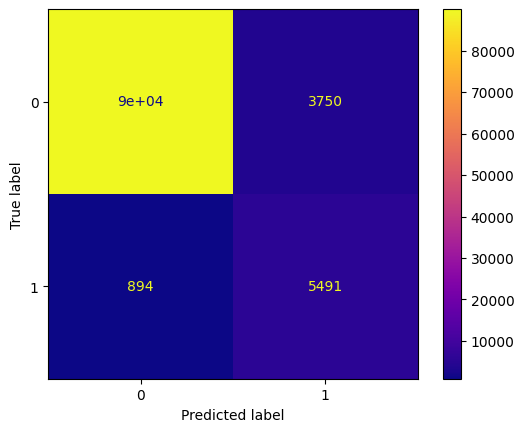

In [ ]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap='plasma')

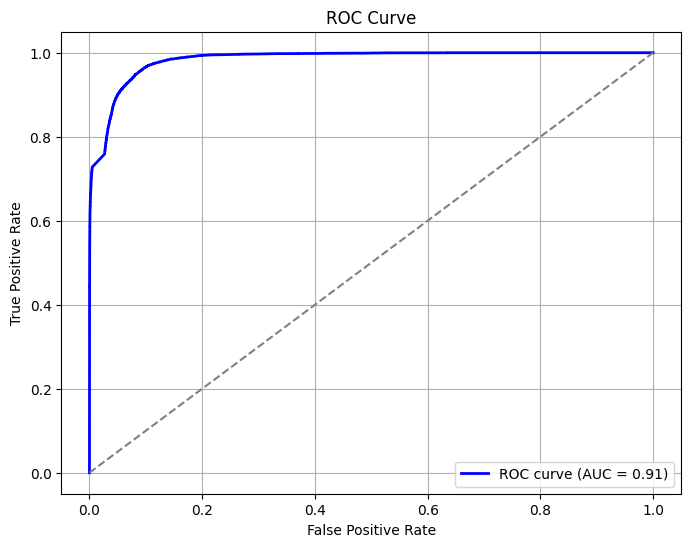

In [ ]:
# Calculate predicted probabilities for the positive class
y_pred_prob = rf.predict_proba(X_test_normalized)[:, 1]

# Compute false positive rate (fpr) and true positive rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute ROC AUC score
roc_auc = roc_auc_score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# References


*   Oprea, S.-V., & Bâra, A. (2021). Machine learning classification algorithms and anomaly detection in conventional meters and Tunisian electricity consumption large datasets. Computers &amp; Electrical Engineering, 94, 107329. https://doi.org/10.1016/j.compeleceng.2021.107329
*   Rubaidi, Z. S., Ammar, B. B., & Aouicha, M. B. (2022). Fraud detection using large-scale imbalance dataset. International Journal on Artificial Intelligence Tools, 31(08). https://doi.org/10.1142/s0218213022500373



In text citation:


*   (Oprea & Bâra, 2021)
*   (Rubaidi et al., 2022)

